# Jupyter Notebook to develop and train an artificial neural networks for the Trader bot

In [188]:
import psycopg2
import tensorflow as tf
import numpy as np
import pandas as pd
import mplfinance as mpf
import matplotlib.pyplot as plt

# Exanges fess
SELL_FEES = 0.005 
BUY_FEES = 0.005

## Data acquisition

In [ ]:
DB_URL = "https://trader.derveloy.eu/"
DB_NAME = "trader_bot"
DB_PORT = 5432
DB_USER = "grafana_readonly"
DB_PASSWORD = str(input("Enter your postgress password: "))

### Database table's structure

```
CREATE TABLE IF NOT EXISTS public.candles
(
    "time" timestamp with time zone NOT NULL,
    symbol character varying(20) COLLATE pg_catalog."default" NOT NULL,
    timeframe character varying(10) COLLATE pg_catalog."default" NOT NULL,
    open numeric(20,8) NOT NULL,
    high numeric(20,8) NOT NULL,
    low numeric(20,8) NOT NULL,
    close numeric(20,8) NOT NULL,
    volume numeric(20,8) NOT NULL,
    CONSTRAINT candles_pkey PRIMARY KEY ("time", symbol, timeframe)
)
```

### Download bitcoin history data

In [14]:
from urllib.parse import urlparse

# Extract hostname from DB_URL (handles URLs with or without http/https)
db_host = urlparse(DB_URL).hostname if "://" in DB_URL else DB_URL.strip("/")

# Connect to the PostgreSQL database
conn = psycopg2.connect(
    host=db_host,
    port=DB_PORT,
    database=DB_NAME,
    user=DB_USER,
    password=DB_PASSWORD
)

# Query bitcoin historical candles using the table's schema:
# public.candles("time", symbol, timeframe, open, high, low, close, volume)
query = """
SELECT 
    "time",
    symbol,
    timeframe,
    open,
    high,
    low,
    close,
    volume
FROM public.candles
WHERE symbol ILIKE '%BTC%'
ORDER BY "time" ASC;
"""

df_btc = pd.read_sql_query(query, conn)

# Close the database connection
conn.close()

# Convert columns according to the table schema
df_btc["time"] = pd.to_datetime(df_btc["time"])
numeric_cols = ["open", "high", "low", "close", "volume"]
df_btc[numeric_cols] = df_btc[numeric_cols].astype(float)

print(f"Downloaded {len(df_btc)} candles.")
if not df_btc.empty:
    print("Symbols found:", df_btc["symbol"].unique())
    print("Timeframes found:", df_btc["timeframe"].unique())
    print("Time range:", df_btc["time"].min(), "to", df_btc["time"].max())

df_btc.head()

C:\Users\louis\AppData\Local\Temp\ipykernel_24968\3472934930.py:32: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_btc = pd.read_sql_query(query, conn)


Downloaded 252311 candles.
Symbols found: <StringArray>
['BTCUSDC']
Length: 1, dtype: str
Timeframes found: <StringArray>
['15m']
Length: 1, dtype: str
Time range: 2018-12-15 03:00:00+00:00 to 2026-09-03 09:00:00+00:00


,time,symbol,timeframe,open,high,low,close,volume
0,2018-12-15 03:00:00+00:00,BTCUSDC,15m,3200.00,3312.32,3000.00,3312.32,1.885233
1,2018-12-15 03:15:00+00:00,BTCUSDC,15m,3283.09,3283.09,3218.34,3218.34,0.082722
2,2018-12-15 03:30:00+00:00,BTCUSDC,15m,3222.02,3223.49,3206.19,3223.49,0.212581
3,2018-12-15 03:45:00+00:00,BTCUSDC,15m,3221.73,3225.97,3205.60,3225.97,0.193470
4,2018-12-15 04:00:00+00:00,BTCUSDC,15m,3225.97,3225.97,3205.58,3205.63,0.928241


In [13]:
if not df_btc.empty:
    print("Time range:", df_btc["time"].min(), "to", df_btc["time"].max())

Time range: 2023-03-12 06:30:00+00:00 to 2026-09-03 08:30:00+00:00


### Save data to file system

In [15]:
# Save DataFrame to CSV in the data directory
df_btc.to_csv("data/bitcoin_candles.csv", index=False)
print("Data saved to data/bitcoin_candles.csv")

Data saved to data/bitcoin_candles.csv


### Load data from file system

findfont: Failed to find font weight semibold, now using 700.


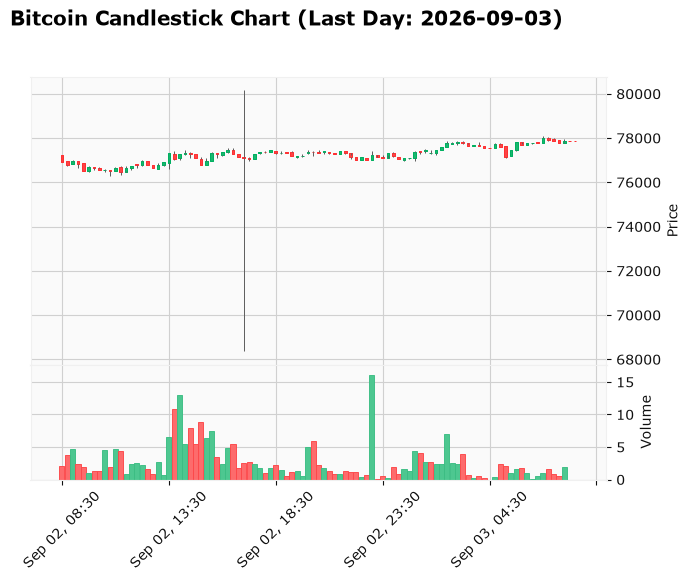

In [12]:
# Prepare DataFrame for mplfinance (requires DatetimeIndex and capitalized OHLCV columns)
df_plot = df_btc.rename(columns={
    "open": "Open",
    "high": "High",
    "low": "Low",
    "close": "Close",
    "volume": "Volume"
}).set_index("time")

# Filter candles for the last day (last 24 hours of data)
last_timestamp = df_plot.index.max()
df_last_day = df_plot[df_plot.index >= (last_timestamp - pd.Timedelta(days=1))]

# Plot candlestick chart with volume
mpf.plot(
    df_last_day,
    type="candle",
    volume=True,
    style="yahoo",
    title=f"Bitcoin Candlestick Chart (Last Day: {last_timestamp.strftime('%Y-%m-%d')})"
)

## Data treatment

### Spliting data set
Let's start with a 1 year test set and everything else for training

In [22]:
last_timestamp = df_plot.index.max()
div_timestamp = last_timestamp - pd.Timedelta(days=365)

test_data = df_btc[df_btc["time"] >= div_timestamp]
train_data = df_btc[df_btc["time"] < div_timestamp]

In [27]:
print(test_data["time"].max())
print(test_data["time"].min())
print(train_data["time"].max())
print(train_data["time"].min())

2026-09-03 09:00:00+00:00
2025-09-03 08:30:00+00:00
2025-09-03 08:15:00+00:00
2018-12-15 03:00:00+00:00


## Generating labels

### Max drawdown tolerance
First let's define a fonction, `max_drawdown_tolerance()`. This fonction will tell use how much we can go down before closing a position. So the labels doesn't push the model to close the position the first time the price go down. Here is an illustration.

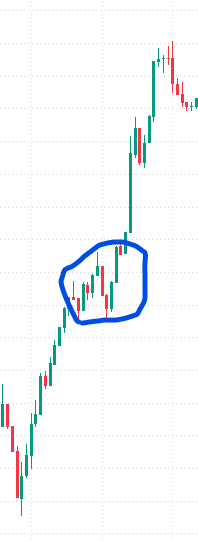

Here we don't want to close the position when we arrive in the blue circle but only at the very top so that we can spend less money on fees.
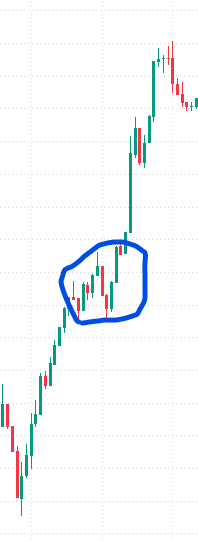

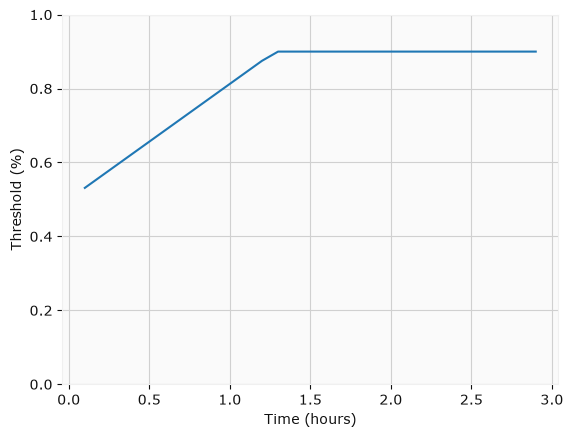

In [89]:
def max_drawdown_tolerance(dt: pd.Timedelta) -> float:
    """
    Calculates the maximum drawdown tolerance for a given transaction duration.
    :param dt: Duration of the transaction so far.
    """
    CROP_DURATION = 14400 # 14,400 = 4 * 3600 = 4 heures
    
    dt = min(CROP_DURATION, dt.total_seconds())

    value = 0.5 + (3/4)*(dt/CROP_DURATION)
    
    return min(0.9, value)
    
fig, ax = plt.subplots()
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Threshold (%)")
ax.set_ylim(0,1)
ax.plot(np.arange(0.1, 3.0, 0.1) , [max_drawdown_tolerance(dt=pd.Timedelta(seconds=x*600)) for x in range(1, 30, 1)])

### Generating labels

In [106]:
print(train_data.iloc[0].keys())
print(len(train_data))
print(type(train_data))
print(train_data.shape)
print(type(train_data.iloc[0]))

Index(['time', 'symbol', 'timeframe', 'open', 'high', 'low', 'close',
       'volume'],
      dtype='str')
219578
<class 'pandas.DataFrame'>
(219578, 8)
<class 'pandas.Series'>


In [110]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 219578 entries, 0 to 219577
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype              
---  ------     --------------   -----              
 0   time       219578 non-null  datetime64[us, UTC]
 1   symbol     219578 non-null  str                
 2   timeframe  219578 non-null  str                
 3   open       219578 non-null  float64            
 4   high       219578 non-null  float64            
 5   low        219578 non-null  float64            
 6   close      219578 non-null  float64            
 7   volume     219578 non-null  float64            
dtypes: datetime64[us, UTC](1), float64(5), str(2)
memory usage: 13.4 MB


In [138]:
def is_green(candles: pd.Series) -> bool:
    return candles["open"] < candles["close"]

In [154]:
def is_profitable_with_fees(buy: pd.Series, sell: pd.Series) -> tuple[bool, float]:
    buy_price = buy["close"]
    sell_price = sell["close"]

    # Calculate how much capital remains after the price change and both fees
    # Formula: (Sell / Buy) * (1 - Buy_Fee) * (1 - Sell_Fee)
    capital_multiplier = (sell_price / buy_price) * (1 - BUY_FEES) * (1 - SELL_FEES)

    # It is profitable if your final capital multiplier is strictly greater than 1 (100%)
    return (capital_multiplier > 1.0, capital_multiplier)

In [173]:
def generate_labels(dataframe: pd.DataFrame, END_INDEX = None) -> pd.DataFrame:
    index: int = 0
    positions: list[list[int]] = [] # [[ouverture, fermeture], ..., ..., ...]

    END_INDEX = END_INDEX if END_INDEX is not None else dataframe.shape[0] 
    while index < END_INDEX:
        
        if is_green(dataframe.iloc[index]): # If the bitcoin is going down we skip the candles until it goes up.
            start_candle = index
            
            max_price = max(dataframe.iloc[index]["close"], dataframe.iloc[index]["open"])
            
            while index < END_INDEX:
                last_candle = index
                index += 1

                if index >= END_INDEX:
                    break
                    
                max_price = max(max_price, max(dataframe.iloc[index]["close"], dataframe.iloc[index]["open"]))
                
                if not is_green(dataframe.iloc[index]): # We wait until it start to go down again
                    
                    if not ( (dataframe.iloc[index]["close"] - dataframe.iloc[start_candle]["open"])/(max_price-dataframe.iloc[start_candle]["open"]) > max_drawdown_tolerance(dataframe.iloc[last_candle]["time"] - dataframe.iloc[start_candle]["time"]) ): # Check if we're in the max_dropdown threshold
                        
                        # Combining position with the last trade or create a new trade
                        if (len(positions) > 0) \
                                and (dataframe.iloc[positions[-1][1]]["time"] - dataframe.iloc[start_candle]["time"] < pd.Timedelta(hours=1.5)) \
                                and (dataframe.iloc[positions[-1][1]]["close"] < dataframe.iloc[start_candle]["close"]):
                            positions[-1][1] = last_candle # last_candle because we want to sell before it went down.
                            break
                        else:
                            if start_candle != last_candle:
                                positions.append([start_candle, last_candle])
                            break
                    
        else:
            index += 1

    ret = dataframe.copy()
    ret["type"] = "hold"
    ret["capital_multiplier"] = float(1)

    for start_candle, last_candle in positions:

        is_profitable, capital_multiplier = is_profitable_with_fees(dataframe.iloc[start_candle], dataframe.iloc[last_candle])
        
        if is_profitable:
            ret.loc[dataframe.index[start_candle], "type"] = "buy"
            ret.loc[dataframe.index[last_candle], "type"] = "sell"
            ret.loc[dataframe.index[last_candle], "capital_multiplier"] = capital_multiplier
            

    return ret

### Test labeling

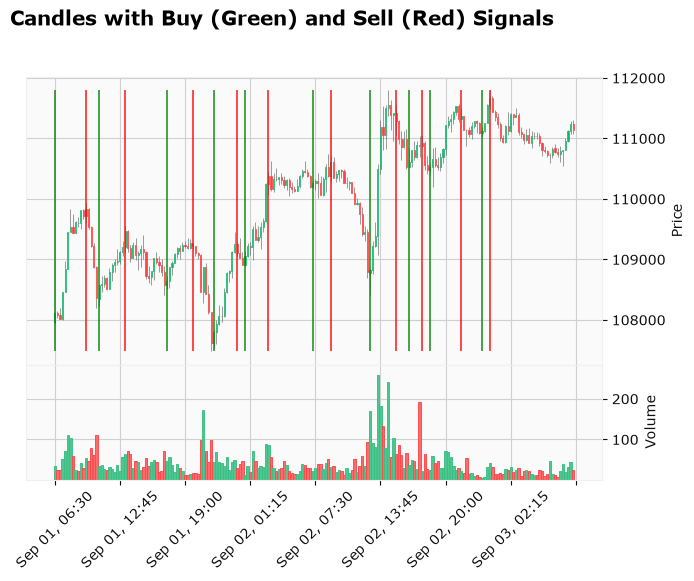

In [185]:
import mplfinance as mpf

# 1. Take a subset of your data so the plot is readable (e.g., the last 200 candles)
df_subset = train_data.tail(200).copy()

# 2. Generate the labels using your function
df_labeled = generate_labels(df_subset)

# 3. Prepare the DataFrame for mplfinance (requires DatetimeIndex and capitalized OHLCV columns)
df_plot = df_labeled.rename(columns={
    "open": "Open",
    "high": "High",
    "low": "Low",
    "close": "Close",
    "volume": "Volume"
}).set_index("time")

# 4. Extract timestamps where the type is 'buy' or 'sell'
buy_dates = df_plot[df_plot["type"] == "buy"].index.tolist()
sell_dates = df_plot[df_plot["type"] == "sell"].index.tolist()

# 5. Combine dates and assign green ('g') to buys and red ('r') to sells
vlines_dates = buy_dates + sell_dates
vlines_colors = ["g"] * len(buy_dates) + ["r"] * len(sell_dates)

# 6. Plot the candlestick chart
if vlines_dates:
    # We pass the dates and colors to the vlines argument
    vlines_kwargs = dict(vlines=vlines_dates, colors=vlines_colors, linewidths=0.1, alpha=0.7)
    mpf.plot(
        df_plot,
        type="candle",
        style="yahoo",
        volume=True,
        vlines=vlines_kwargs,
        title="Candles with Buy (Green) and Sell (Red) Signals"
    )
else:
    print("No buy/sell signals in this range.")
    mpf.plot(
        df_plot,
        type="candle",
        style="yahoo",
        volume=True,
        title="Candles (No signals)"
    )

### Test theorical output 

In [198]:
temp = generate_labels(train_data)

global output:  5.6772528325534184e+16
mean:  1.0001784640998748
nb of positions:  3368


<Axes: title={'center': 'Distribution of Trade Gains (%)'}, xlabel='Profit (%)', ylabel='Frequency'>

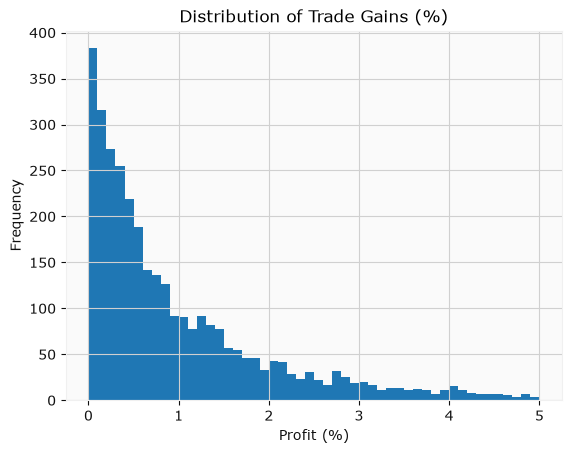

In [199]:
print("global output: ", temp["capital_multiplier"].prod())
print("mean: ", temp["capital_multiplier"].mean())
print("nb of positions: ", len(temp[temp["type"] == "sell"]))


# 1. Isolate the sell candles and convert multiplier to profit percentage
sells = temp[temp["type"] == "sell"].copy()
sells["profit_pct"] = (sells["capital_multiplier"] - 1) * 100

# 2. Define the ranges (bins) and their labels
bins = [0, 1, 2, 3, 4, 5, 10, float("inf")]
labels = ["0% to 1%", "1% to 2%", "2% to 3%", "3% to 4%", "4% to 5%", "5% to 10%", "> 10%"]

# 3. Cut into brackets and count occurrences
sells["bracket"] = pd.cut(sells["profit_pct"], bins=bins, labels=labels, right=False)
(temp[temp["type"] == "sell"]["capital_multiplier"].sub(1) * 100).plot(
    kind="hist",
    bins=50,
    range=(0, 5),
    title="Distribution of Trade Gains (%)",
    xlabel="Profit (%)",
    grid=True)